In [1]:
import pandas as pd
import numpy as np

# 1. Load the single source of truth
df = pd.read_parquet('analytical_base_table_raw.parquet', engine='pyarrow')

In [11]:
# Show all columns
pd.set_option('display.max_columns', None)

In [12]:
df.head()

,CREDIT_SCORE,FIRST_PAYMENT_DATE,FIRST_TIME_BUYER,MATURITY_DATE,MSA,MI_PERCENT,NUMBER_UNITS,OCCUPANCY_STATUS,CLTV,DTI,ORIGINAL_UPB,LTV,ORIGINAL_INTEREST_RATE,CHANNEL,PPM,AMORTIZATION_TYPE,PROPERTY_STATE,PROPERTY_TYPE,POSTAL_CODE,LOAN_SEQUENCE_NUMBER,LOAN_PURPOSE,ORIGINAL_LOAN_TERM,NUMBER_BORROWERS,SELLER_NAME,SERVICER_NAME,SUPER_CONFORMING_FLAG,PRE_HARP_LOAN_SEQ_NUM,SPECIAL_ELIGIBILITY_PROGRAM,HARP_INDICATOR,PROPERTY_VALUATION_METHOD,INTEREST_ONLY_INDICATOR,VANTAGE_SCORE_4,ORIGINATION_YEAR,LOAN_LIFESPAN_MONTHS,TOTAL_ACTUAL_LOSS,MAX_DELINQUENCY_STATUS,TIMES_30_DAYS_LATE,TIMES_60_DAYS_LATE,RATE_INCREASE_MAGNITUDE,FINAL_UPB_RATIO,EVER_MODIFIED,DEFAULT_INDICATOR
0,742,200802,N,203801,41500.0,0,1,P,39,42,265000,39,5.750,T,N,FRM,CA,SF,93900,F07Q40337112,C,360,1,Other sellers,Other servicers,None,None,9,None,7,N,9,2008,33,0.0,0,0,0,0.0,0.0,0,0
1,734,200802,N,203801,33460.0,12,1,I,85,35,197000,85,6.625,R,N,FRM,MN,PU,55300,F07Q40342482,N,360,1,Other sellers,Other servicers,None,None,9,None,7,N,9,2008,107,0.0,0,0,0,0.0,0.0,0,0
2,667,200802,N,203801,45300.0,25,1,P,90,28,257000,90,6.500,R,N,FRM,FL,SF,33600,F07Q40344038,C,360,1,WASHINGTON MUTUAL BANK,"SELECT PORTFOLIO SERVICING, INC.",None,None,9,None,7,N,9,2008,81,0.0,43,19,19,2.5,0.0,1,1
3,725,200802,N,203801,47260.0,25,1,I,86,48,122000,86,6.875,T,N,FRM,VA,SF,23300,F07Q40346958,N,360,1,"GMAC MORTGAGE, LLC","GMAC MORTGAGE, LLC",None,None,9,None,7,N,9,2008,58,0.0,0,0,0,0.0,0.0,0,0
4,777,200802,N,203801,33340.0,0,1,P,55,46,417000,55,5.750,T,N,FRM,WI,SF,53000,F07Q40344621,N,360,2,"TAYLOR, BEAN & WHITAKER MORTGAGE CORP.","TAYLOR, BEAN & WHITAKER MORTGAGE CORP.",None,None,9,None,7,N,9,2008,13,0.0,0,0,0,0.0,0.0,0,0


In [13]:
df.shape

(150000, 42)

In [75]:
df.columns

Index(['CREDIT_SCORE', 'FIRST_PAYMENT_DATE', 'FIRST_TIME_BUYER',
       'MATURITY_DATE', 'MSA', 'MI_PERCENT', 'NUMBER_UNITS',
       'OCCUPANCY_STATUS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV',
       'ORIGINAL_INTEREST_RATE', 'CHANNEL', 'PPM', 'AMORTIZATION_TYPE',
       'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE',
       'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'ORIGINAL_LOAN_TERM',
       'NUMBER_BORROWERS', 'SELLER_NAME', 'SERVICER_NAME',
       'SUPER_CONFORMING_FLAG', 'PRE_HARP_LOAN_SEQ_NUM',
       'SPECIAL_ELIGIBILITY_PROGRAM', 'HARP_INDICATOR',
       'PROPERTY_VALUATION_METHOD', 'INTEREST_ONLY_INDICATOR',
       'VANTAGE_SCORE_4', 'ORIGINATION_YEAR', 'LOAN_LIFESPAN_MONTHS',
       'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE',
       'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO',
       'EVER_MODIFIED', 'DEFAULT_INDICATOR', 'JOIN_YEAR_MONTH'],
      dtype='str')

# EDA

In [20]:
target = 'DEFAULT_INDICATOR'

In [22]:
df.DEFAULT_INDICATOR.value_counts()

DEFAULT_INDICATOR
0    129016
1     20984
Name: count, dtype: int64

In [76]:
df.PROPERTY_VALUATION_METHOD.value_counts()

PROPERTY_VALUATION_METHOD
7    150000
Name: count, dtype: int64

## Variance Threshold Selection
8 variables dropped

In [77]:
# Drop the constant/zeroVariance column from your dataframe
df = df.drop(columns=['PROPERTY_VALUATION_METHOD'])


In [80]:
# 1. Identify columns with exactly 1 unique value (or 0 if entirely empty)
constant_cols = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]

# 2. Print results cleanly
print(f"Found {len(constant_cols)} zero-variance column(s):")
print(constant_cols)

Found 7 zero-variance column(s):
['AMORTIZATION_TYPE', 'SUPER_CONFORMING_FLAG', 'PRE_HARP_LOAN_SEQ_NUM', 'SPECIAL_ELIGIBILITY_PROGRAM', 'HARP_INDICATOR', 'INTEREST_ONLY_INDICATOR', 'VANTAGE_SCORE_4']


In [89]:
pd.DataFrame([{"Column": col, "Value": df[col].unique()[0], "Count": len(df)} for col in constant_cols])

,Column,Value,Count
0,AMORTIZATION_TYPE,FRM,150000
1,SUPER_CONFORMING_FLAG,None,150000
2,PRE_HARP_LOAN_SEQ_NUM,None,150000
3,SPECIAL_ELIGIBILITY_PROGRAM,9,150000
4,HARP_INDICATOR,None,150000
5,INTEREST_ONLY_INDICATOR,N,150000
6,VANTAGE_SCORE_4,9,150000


In [81]:
df.AMORTIZATION_TYPE.value_counts()

AMORTIZATION_TYPE
FRM    150000
Name: count, dtype: int64

In [82]:
df.INTEREST_ONLY_INDICATOR.value_counts()

INTEREST_ONLY_INDICATOR
N    150000
Name: count, dtype: int64

In [84]:
df.SUPER_CONFORMING_FLAG.value_counts()

Series([], Name: count, dtype: int64)

short, macroeconomic reality of what these flatline values mean:

AMORTIZATION_TYPE: FRM & INTEREST_ONLY_INDICATOR: N: Your entire portfolio consists exclusively of traditional, fully amortizing Fixed-Rate Mortgages. You are looking at the standard "prime/conventional" structural baseline, completely free of toxic, complex structural triggers like interest-only payment cliffs.

SUPER_CONFORMING_FLAG: None & HARP_INDICATOR: None & SPECIAL_ELIGIBILITY_PROGRAM: 9: The value 9 is an industry filler code meaning "Not Applicable." This confirms these assets were underwritten under standard Fannie Mae / Freddie Mac guidelines. They contain zero specialized government intervention cohorts or post-crash relief programs (like the Home Affordable Refinance Program).

VANTAGE_SCORE_4: 9: The score is unpopulated (coded as 9 for missing). Lenders during the 2005–2008 era relied almost entirely on traditional FICO scores, meaning this specific newer credit bureau model wasn't used to evaluate borrower risk.

Property_Valuation_Method:The constant value 7 is the Fannie Mae/Freddie Mac standard industry filler code for "Not Available" or "Unknown", proving that specific property appraisal methodology tracking was completely omitted or unrecorded during this vintage era.

In [91]:
df.drop(columns=constant_cols, errors='ignore', inplace=True)

In [93]:
df.shape

(150000, 35)

1 var more as a custom var was created and this was done later

## Segregation of Vars

In [94]:
# =========================================================================
# PHASE 1: PROGRAMMATIC VARIABLE CATEGORIZATION
# =========================================================================

temporal_features = []
categorical_features = []
numerical_features = []

In [95]:
time_keywords = ['YEAR', 'DATE', 'MONTH', 'VINTAGE', 'TIMESTAMP', 'QUARTER']

for col in df.columns:
    # 1. If it looks like a date, it's temporal
    if pd.api.types.is_datetime64_any_dtype(df[col]) or any(kw in col.upper() for kw in time_keywords):
        temporal_features.append(col)
        
    # 2. If it's a number, it's numerical
    elif pd.api.types.is_numeric_dtype(df[col]):
        numerical_features.append(col)
        
    # 3. Catch-All: Anything else left standing MUST be categorical
    else:
        categorical_features.append(col)

In [96]:
temporal_features

['FIRST_PAYMENT_DATE',
 'MATURITY_DATE',
 'ORIGINATION_YEAR',
 'LOAN_LIFESPAN_MONTHS',
 'JOIN_YEAR_MONTH']

In [97]:
print(len(categorical_features))
print(categorical_features)


11
['FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'SELLER_NAME', 'SERVICER_NAME']


In [98]:
print(len(numerical_features))
print(numerical_features)

19
['CREDIT_SCORE', 'MSA', 'MI_PERCENT', 'NUMBER_UNITS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'NUMBER_BORROWERS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'DEFAULT_INDICATOR']


In [ ]:
# Remove target from standard numerical evaluation pool
target = 'DEFAULT_INDICATOR'

numerical_features.remove('DEFAULT_INDICATOR')

In [101]:
df.MSA.value_counts()

MSA
16974.0    4499
38060.0    2894
12060.0    2674
26420.0    2393
31084.0    2355
           ... 
11640.0       1
21794.0       1
48680.0       1
38240.0       1
49500.0       1
Name: count, Length: 450, dtype: int64

In [100]:
# 3. Shift 'MSA' from Numerical to Categorical
if 'MSA' in numerical_features:
    numerical_features.remove('MSA')
    categorical_features.append('MSA')

In [114]:
print(len(numerical_features))
print(numerical_features)

18
['CREDIT_SCORE', 'MI_PERCENT', 'NUMBER_UNITS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'NUMBER_BORROWERS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'LOAN_LIFESPAN_MONTHS']


In [115]:
print(len(categorical_features))
print(categorical_features)


12
['FIRST_TIME_BUYER', 'OCCUPANCY_STATUS', 'CHANNEL', 'PPM', 'PROPERTY_STATE', 'PROPERTY_TYPE', 'POSTAL_CODE', 'LOAN_SEQUENCE_NUMBER', 'LOAN_PURPOSE', 'SELLER_NAME', 'SERVICER_NAME', 'MSA']


In [26]:
df.LOAN_LIFESPAN_MONTHS.head(100)

0      33
1     107
2      81
3      58
4      13
     ... 
95     55
96     90
97     66
98     93
99     96
Name: LOAN_LIFESPAN_MONTHS, Length: 100, dtype: int64

## Temporale Variables EDA

### Temporal EDA Executive Summary

---

### Data Integrity and Completeness
* **Missing Data:** 0.00% missing values across all four primary temporal attributes (Origination Year, Loan Lifespan Months, First Payment Date, and Maturity Date), establishing a complete chronological baseline.
* **Granularity:** The dataset functions at a monthly granularity, with data fields structurally capturing monthly cohorts across the credit cycle.

---

### Key Empirical Highlights

#### 1. Underwriting Volume and Vintage Risk
* **Market Cycle Dynamics:** Loan origination and initial payment distributions capture the classic subprime expansion, peaking aggressively through the 2006–2007 window. 
* **Liquidity Freeze:** A steep contraction is observed in 2008, indexing the systemic freeze in credit markets during the global recession.
* **Data Pruning Priority:** Realized default rates escalate from ~10.5% (2005) to over 17% (2007–2008). Post-2009 data exhibits extreme small-sample volatility, flatlining at an artificial 25% default rate due to negligible loan volumes; these cohorts require filtering before model training.

#### 2. Portfolio Seasoning and Duration Analysis
* **Peak Seasoning Window:** The continuous distribution of loan lifespans is heavily right-skewed, demonstrating a sharp concentration of asset terminations between 20 and 50 months.
* **Survival Baseline:** The median operational lifespan of a loan in this portfolio is 55 months, with the interquartile range concentrated between 30 and 85 months. True long-term survival past 165 months represents statistical outperformance.

#### 3. Asset-Liability Horizon Structure
* **Product Segmentation:** Maturity dates reveal a clear structural split within the underwriting book, isolating a minor volume of 15-year fixed-rate notes (maturing 2020–2023) and a dominant concentration of conventional 30-year mortgages (maturing 2035–2038).

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set publication style metrics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

Matplotlib is building the font cache; this may take a moment.


In [35]:
df.FIRST_PAYMENT_DATE.describe

<bound method NDFrame.describe of 0         200802
1         200802
2         200802
3         200802
4         200802
           ...  
149995    200511
149996    200504
149997    200504
149998    200602
149999    200711
Name: FIRST_PAYMENT_DATE, Length: 150000, dtype: int64>

In [36]:
df.MATURITY_DATE.describe

<bound method NDFrame.describe of 0         203801
1         203801
2         203801
3         203801
4         203801
           ...  
149995    203510
149996    202003
149997    203503
149998    203601
149999    203710
Name: MATURITY_DATE, Length: 150000, dtype: int64>

In [ ]:
#  Convert the YYYYMM integers to clean, readable dates
df['MATURITY_DATE'] = pd.to_datetime(df['MATURITY_DATE'].astype(str), format='%Y%m')

In [45]:
df.MATURITY_DATE.describe


<bound method NDFrame.describe of 0        2038-01-01
1        2038-01-01
2        2038-01-01
3        2038-01-01
4        2038-01-01
            ...    
149995   2035-10-01
149996   2020-03-01
149997   2035-03-01
149998   2036-01-01
149999   2037-10-01
Name: MATURITY_DATE, Length: 150000, dtype: datetime64[us]>

In [46]:
df['FIRST_PAYMENT_DATE'] = pd.to_datetime(df['FIRST_PAYMENT_DATE'].astype(str), format='%Y%m')

In [47]:
df.FIRST_PAYMENT_DATE.describe

<bound method NDFrame.describe of 0        2008-02-01
1        2008-02-01
2        2008-02-01
3        2008-02-01
4        2008-02-01
            ...    
149995   2005-11-01
149996   2005-04-01
149997   2005-04-01
149998   2006-02-01
149999   2007-11-01
Name: FIRST_PAYMENT_DATE, Length: 150000, dtype: datetime64[us]>

In [37]:
# Ensure date columns are parsed into standardized datetime objects for profiling
for date_col in ['FIRST_PAYMENT_DATE', 'MATURITY_DATE']:
    if date_col in df.columns and not pd.api.types.is_datetime64_any_dtype(df[date_col]):
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')

In [38]:
df.FIRST_PAYMENT_DATE.describe

<bound method NDFrame.describe of 0        1970-01-01 00:00:00.000200802
1        1970-01-01 00:00:00.000200802
2        1970-01-01 00:00:00.000200802
3        1970-01-01 00:00:00.000200802
4        1970-01-01 00:00:00.000200802
                      ...             
149995   1970-01-01 00:00:00.000200511
149996   1970-01-01 00:00:00.000200504
149997   1970-01-01 00:00:00.000200504
149998   1970-01-01 00:00:00.000200602
149999   1970-01-01 00:00:00.000200711
Name: FIRST_PAYMENT_DATE, Length: 150000, dtype: datetime64[ns]>

In [39]:
df.MATURITY_DATE.describe

<bound method NDFrame.describe of 0        1970-01-01 00:00:00.000203801
1        1970-01-01 00:00:00.000203801
2        1970-01-01 00:00:00.000203801
3        1970-01-01 00:00:00.000203801
4        1970-01-01 00:00:00.000203801
                      ...             
149995   1970-01-01 00:00:00.000203510
149996   1970-01-01 00:00:00.000202003
149997   1970-01-01 00:00:00.000203503
149998   1970-01-01 00:00:00.000203601
149999   1970-01-01 00:00:00.000203710
Name: MATURITY_DATE, Length: 150000, dtype: datetime64[ns]>

In [48]:
print(df[['FIRST_PAYMENT_DATE', 'MATURITY_DATE']].head())

  FIRST_PAYMENT_DATE MATURITY_DATE
0         2008-02-01    2038-01-01
1         2008-02-01    2038-01-01
2         2008-02-01    2038-01-01
3         2008-02-01    2038-01-01
4         2008-02-01    2038-01-01


In [49]:
df.LOAN_LIFESPAN_MONTHS.describe

<bound method NDFrame.describe of 0          33
1         107
2          81
3          58
4          13
         ... 
149995      2
149996      1
149997      2
149998      1
149999      1
Name: LOAN_LIFESPAN_MONTHS, Length: 150000, dtype: int64>

In [53]:
df.ORIGINATION_YEAR.describe

<bound method NDFrame.describe of 0         2008
1         2008
2         2008
3         2008
4         2008
          ... 
149995    2005
149996    2005
149997    2005
149998    2006
149999    2007
Name: ORIGINATION_YEAR, Length: 150000, dtype: int64>

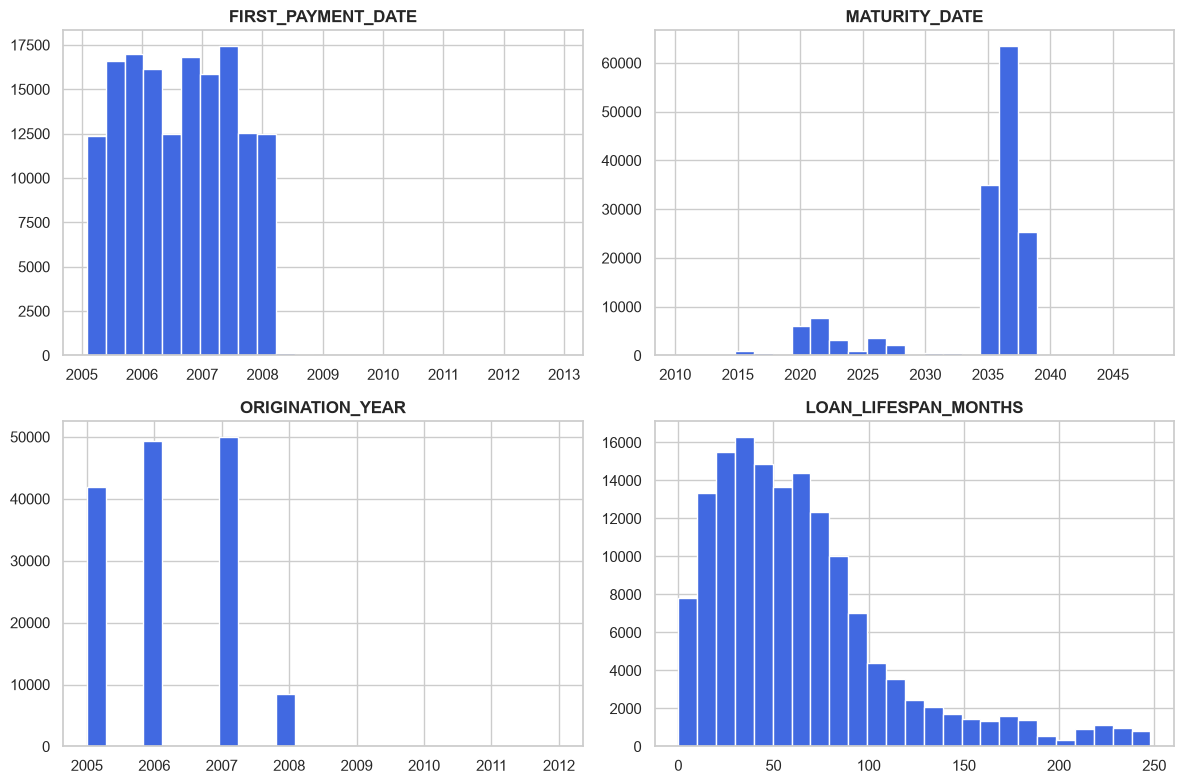

In [54]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for col, ax in zip(['FIRST_PAYMENT_DATE', 'MATURITY_DATE', 'ORIGINATION_YEAR', 'LOAN_LIFESPAN_MONTHS'], axs.ravel()):
    ax.hist(df[col].dropna(), bins=25, color='royalblue', edgecolor='white')
    ax.set_title(col, fontweight='bold')
plt.tight_layout(); plt.savefig('temporal_raw_plots.png')

In [55]:
df['JOIN_YEAR_MONTH'] = df['FIRST_PAYMENT_DATE'].dt.strftime('%Y%m').astype(int)

In [56]:
df.JOIN_YEAR_MONTH.describe

<bound method NDFrame.describe of 0         200802
1         200802
2         200802
3         200802
4         200802
           ...  
149995    200511
149996    200504
149997    200504
149998    200602
149999    200711
Name: JOIN_YEAR_MONTH, Length: 150000, dtype: int64>

In [59]:
temporal_summary = {}

for col in ['ORIGINATION_YEAR', 'LOAN_LIFESPAN_MONTHS', 'FIRST_PAYMENT_DATE', 'MATURITY_DATE']:
    if col in df.columns:
        null_count = df[col].isna().sum()
        null_pct = (null_count / len(df)) * 100
        unique_count = df[col].nunique()
        
        if pd.api.types.is_numeric_dtype(df[col]):
            summary_stats = {
                'Metric Type': 'Numeric Temporal',
                'Min / Earliest': str(df[col].min()),
                'Max / Latest': str(df[col].max()),
                'Mean / Avg': f"{df[col].mean():.2f}",
                'Median (50%)': f"{df[col].median():.2f}",
                'Missing Count': null_count,
                'Missing %': f"{null_pct:.2f}%",
                'Unique Values': unique_count
            }
        else:  # Datetime fields
            summary_stats = {
                'Metric Type': 'Datetime Boundary',
                'Min / Earliest': df[col].min().strftime('%Y-%m-%d') if pd.notnull(df[col].min()) else 'NaT',
                'Max / Latest': df[col].max().strftime('%Y-%m-%d') if pd.notnull(df[col].max()) else 'NaT',
                'Mean / Avg': 'N/A (Datetime)',
                'Median (50%)': df[col].quantile(0.5).strftime('%Y-%m-%d') if pd.notnull(df[col].quantile(0.5)) else 'NaT',
                'Missing Count': null_count,
                'Missing %': f"{null_pct:.2f}%",
                'Unique Values': unique_count
            }
        temporal_summary[col] = summary_stats

# Display structural summary table
df_summary = pd.DataFrame(temporal_summary).T
print("=" * 95)
print(" INDUSTRY DESCRIPTIVE STATISTICS METRIC SUMMARY TABLE: TEMPORAL MATRIX")
print("=" * 95)
print(df_summary.to_string())
print("=" * 95)

 INDUSTRY DESCRIPTIVE STATISTICS METRIC SUMMARY TABLE: TEMPORAL MATRIX
                            Metric Type Min / Earliest Max / Latest      Mean / Avg Median (50%) Missing Count Missing % Unique Values
ORIGINATION_YEAR       Numeric Temporal           2005         2012         2006.17      2006.00             0     0.00%             8
LOAN_LIFESPAN_MONTHS   Numeric Temporal              0          248           64.36        55.00             0     0.00%           249
FIRST_PAYMENT_DATE    Datetime Boundary     2005-02-01   2012-12-01  N/A (Datetime)   2006-09-01             0     0.00%            69
MATURITY_DATE         Datetime Boundary     2010-04-01   2048-01-01  N/A (Datetime)   2036-05-01             0     0.00%           310


We have absolutely zero missing values across all four temporal features.

The major insight is that the dataset extends up to 2012 (not just 2008), meaning we can track the entire macroeconomic cycle from the pre-crisis subprime boom, through the 2008 crash, and into the post-crisis regulatory recovery window. Additionally, a minimum lifespan of 0 months reveals severe immediate credit failures where loans collapsed before making their first scheduled payment.

In [62]:
# Plot 1: Vintage Volume Analysis & Observed Default Rates
if 'ORIGINATION_YEAR' in df.columns and 'DEFAULT_INDICATOR' in df.columns:
    vintage_data = df.groupby('ORIGINATION_YEAR').agg(
        Loan_Count=('DEFAULT_INDICATOR', 'count'),
        Default_Rate=('DEFAULT_INDICATOR', 'mean')
    ).reset_index()
    
    fig1, ax1_left = plt.subplots(figsize=(12, 6))
    
    # Primary Y-Axis: Origination Volume
    sns.barplot(data=vintage_data, x='ORIGINATION_YEAR', y='Loan_Count', color='steelblue', alpha=0.7, ax=ax1_left)
    ax1_left.set_xlabel('Origination Year (Vintage Cohort)', fontsize=12, fontweight='bold')
    ax1_left.set_ylabel('Total Active Loan Count', color='steelblue', fontsize=12, fontweight='bold')
    ax1_left.tick_params(axis='y', labelcolor='steelblue')
    ax1_left.set_title('Risk Profile Breakdown: Underwriting Volume vs. Realized Default Rate Trajectory', fontsize=14, fontweight='bold', pad=15)
    
    # Secondary Y-Axis: Default Rate Percentage
    ax1_right = ax1_left.twinx()
    sns.lineplot(data=vintage_data, x=ax1_left.get_xticks(), y=vintage_data['Default_Rate'] * 100, color='crimson', marker='o', linewidth=2.5, ax=ax1_right)
    ax1_right.set_ylabel('Observed Default Rate (%)', color='crimson', fontsize=12, fontweight='bold')
    ax1_right.tick_params(axis='y', labelcolor='crimson')
    ax1_right.grid(False) # Prevent overlapping grid line confusion
    
    plt.tight_layout()
    #plt.savefig('temporal_eda_vintage_analysis.png')
    plt.close(fig1)
    print(" Figure 1 Saved: 'temporal_eda_vintage_analysis.png'")

 Figure 1 Saved: 'temporal_eda_vintage_analysis.png'


In [67]:
# Plot 2: Loan Lifespan Seasoning Curves and Box Plot Profilesif 'LOAN_LIFESPAN_MONTHS' in df.columns:

fig2, (ax2_top, ax2_bottom) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})


# Top Panel: Seasoning Density

sns.histplot(data=df, x='LOAN_LIFESPAN_MONTHS', kde=True, color='darkslateblue', bins=40, ax=ax2_top)

ax2_top.set_ylabel('Density Frequency Count', fontsize=12, fontweight='bold')

ax2_top.set_title('Portfolio Seasoning Profile: Loan Contractual Lifespan Distribution', fontsize=14, fontweight='bold', pad=15)


# Bottom Panel: Boxplot Spread Outliers

sns.boxplot(data=df, x='LOAN_LIFESPAN_MONTHS', color='mediumpurple', ax=ax2_bottom, width=0.4)

ax2_bottom.set_xlabel('Loan Duration Lifecycle Span (Months)', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig('temporal_eda_lifespan_distribution.png')

plt.close(fig2)

print("💾 Figure 2 Saved: 'temporal_eda_lifespan_distribution.png'")

💾 Figure 2 Saved: 'temporal_eda_lifespan_distribution.png'


In [69]:
# Plot 3: Boundary Timelines Horizon Density

# 1. Create the figure and axis
fig3, ax3 = plt.subplots(figsize=(12, 6))

# 2. Plot First Payment Horizon if data exists
if df['FIRST_PAYMENT_DATE'].notnull().any():
    sns.kdeplot(
        data=df['FIRST_PAYMENT_DATE'].dropna().dt.year, 
        label='First Payment Horizon', 
        color='teal', 
        fill=True, 
        alpha=0.3, 
        ax=ax3
    )

# 3. Plot Maturity Shock Horizon if data exists
if df['MATURITY_DATE'].notnull().any():
    sns.kdeplot(
        data=df['MATURITY_DATE'].dropna().dt.year, 
        label='Maturity Shock Horizon', 
        color='darkorange', 
        fill=True, 
        alpha=0.15, 
        ax=ax3
    )

# 4. Styling and Labels
ax3.set_title('Chronological Footprint: Portfolio Inception vs. Asset Expiration Density Bounds', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('Calendar Horizon Year', fontsize=12, fontweight='bold')
ax3.set_ylabel('Timeline Concentration Density', fontsize=12, fontweight='bold')
ax3.legend(loc='upper right', fontsize=11)

plt.tight_layout()

plt.savefig('temporal_eda_boundary_horizons.png')
plt.close(fig3)
print(" Figure 3 Saved: 'temporal_eda_boundary_horizons.png'")


 Figure 3 Saved: 'temporal_eda_boundary_horizons.png'


## Numerical Vars EDA

In [104]:
# Shift 'LOAN_LIFESPAN_MONTHS' from Temporal to Numerical
if 'LOAN_LIFESPAN_MONTHS' in temporal_features:
    temporal_features.remove('LOAN_LIFESPAN_MONTHS')
    numerical_features.append('LOAN_LIFESPAN_MONTHS')

In [112]:
print(len(numerical_features))
print(numerical_features)

19
['CREDIT_SCORE', 'MI_PERCENT', 'NUMBER_UNITS', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'NUMBER_BORROWERS', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'EVER_MODIFIED', 'DEFAULT_INDICATOR', 'LOAN_LIFESPAN_MONTHS']


In [116]:
discrete_features = []
continuous_features = []

In [117]:
# Hardcoded domain overrides for specific credit constraints 
# (e.g., standard terms or tiered metrics that look discrete but behave continuously)
forced_continuous = {'ORIGINAL_LOAN_TERM', 'MI_PERCENT'}

for col in numerical_features:
    if col in forced_continuous:
        continuous_features.append(col)
        continue
        
    # Drop NaNs just for calculation steps to avoid float pollution
    clean_series = df[col].dropna()
    if clean_series.empty:
        continue
        
    unique_count = clean_series.nunique()
    
    # Mathematical Check: Do any non-missing values contain actual decimals?
    has_decimals = (clean_series % 1 != 0).any()
    
    # Blended Logic Loop
    if has_decimals or unique_count > 25:
        continuous_features.append(col)
    else:
        discrete_features.append(col)

print(f"Continuous Pool ({len(continuous_features)}):", continuous_features)
print(f"Discrete Pool ({len(discrete_features)}):", discrete_features)

Continuous Pool (15): ['CREDIT_SCORE', 'MI_PERCENT', 'CLTV', 'DTI', 'ORIGINAL_UPB', 'LTV', 'ORIGINAL_INTEREST_RATE', 'ORIGINAL_LOAN_TERM', 'TOTAL_ACTUAL_LOSS', 'MAX_DELINQUENCY_STATUS', 'TIMES_30_DAYS_LATE', 'TIMES_60_DAYS_LATE', 'RATE_INCREASE_MAGNITUDE', 'FINAL_UPB_RATIO', 'LOAN_LIFESPAN_MONTHS']
Discrete Pool (3): ['NUMBER_UNITS', 'NUMBER_BORROWERS', 'EVER_MODIFIED']
